# Lesson 3: Adding Forecasting to Priority Bank

Today we’re going to add something really cool to Priority Bank — a way to *guess* how long it will take to save up for your next goal. This is called **forecasting**, and it uses your past saving habits to make smart predictions about the future.
> 👯 **Work in pairs!** One person types (the **Driver**), the other guides (the **Navigator**). Switch roles after each exercise.

### Exercises
1. Identifying data patterns
2. Understand the linear regression algorithm
3. Implement linear regression for Priority Bank

## What is forecasting?
Nobody can see the future, but we can learn from our past! That’s what **forecasting** is all about.

In Priority Bank, every time you save money or move funds between goals, the app remembers it. By looking at your past transactions, we can spot patterns: maybe you save a little each week, or sometimes you get a bigger boost from babysitting. With this information, we can estimate how many days it might take you to reach your next goal, as long as:
1) They continue to act like they always have
2) All savings they make go towards this goal

Think of it like a “time-to-goal” crystal ball — it won’t be perfect, but it will give you a smart guess based on your own habits.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [39]:
data = pd.read_csv("transactions.csv")
data = data.query("type == 'deposit'").copy()
data["date"] = pd.to_datetime(data.date)
data = data.set_index('date')
data = data.sort_index()
data

,goal_id,type,amount,description
date,,,,
2025-09-04,1,deposit,15,Allowance
2025-09-07,1,deposit,10,Weekly save
2025-09-10,1,deposit,18,Chores
2025-09-11,1,deposit,15,Allowance
2025-09-15,1,deposit,22,Babysitting
2025-09-18,1,deposit,8,Snack savings
2025-09-25,1,deposit,15,Allowance
2025-09-28,1,deposit,10,Weekly save
2025-10-02,1,deposit,18,Chores


---
## Exercise 1: Explore data patterns
#@TODO: Write text and give more context

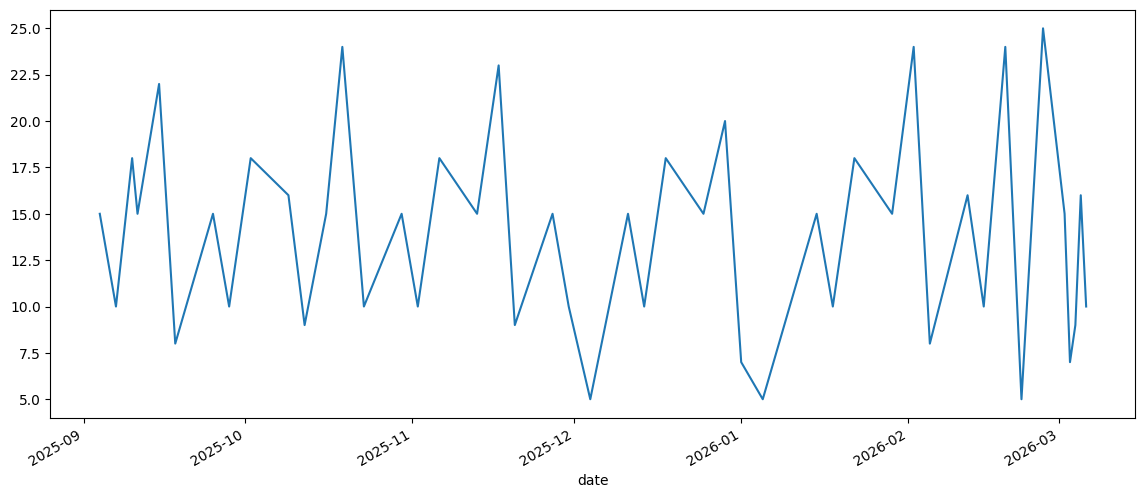

In [41]:
plt.figure(figsize=(14,6))
data.groupby('date').amount.sum().plot()
plt.show()

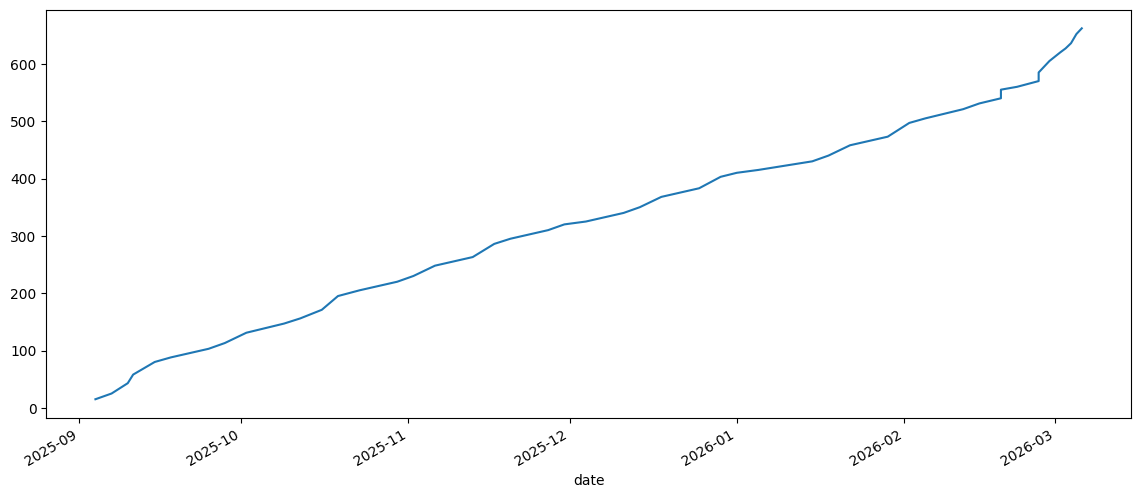

In [43]:
plt.figure(figsize=(14,6))
data['amount'].cumsum().plot()
plt.show()

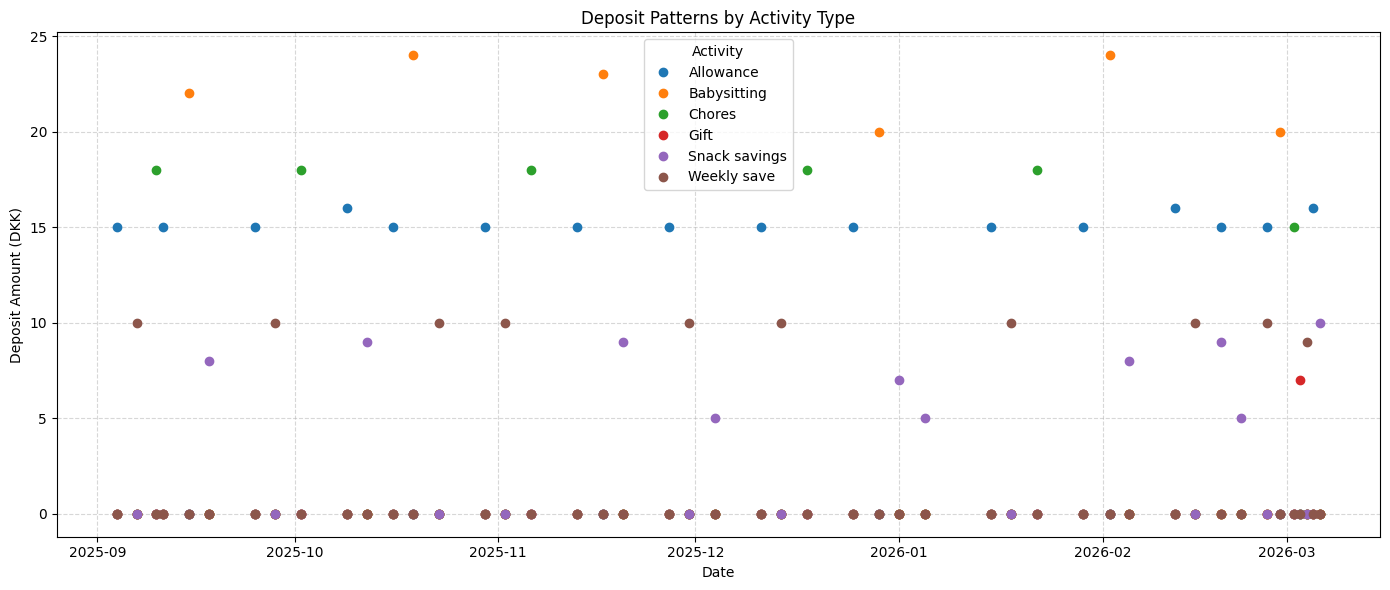

In [53]:
grouped = data.groupby(['date', 'description'])['amount'].sum().unstack(fill_value=0)

plt.figure(figsize=(14,6))
for note in grouped.columns:
    plt.plot(grouped.index, grouped[note], marker='o', linestyle="", label=note)

plt.title("Deposit Patterns by Activity Type")
plt.xlabel("Date")
plt.ylabel("Deposit Amount (DKK)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Activity")
plt.tight_layout()
plt.show()

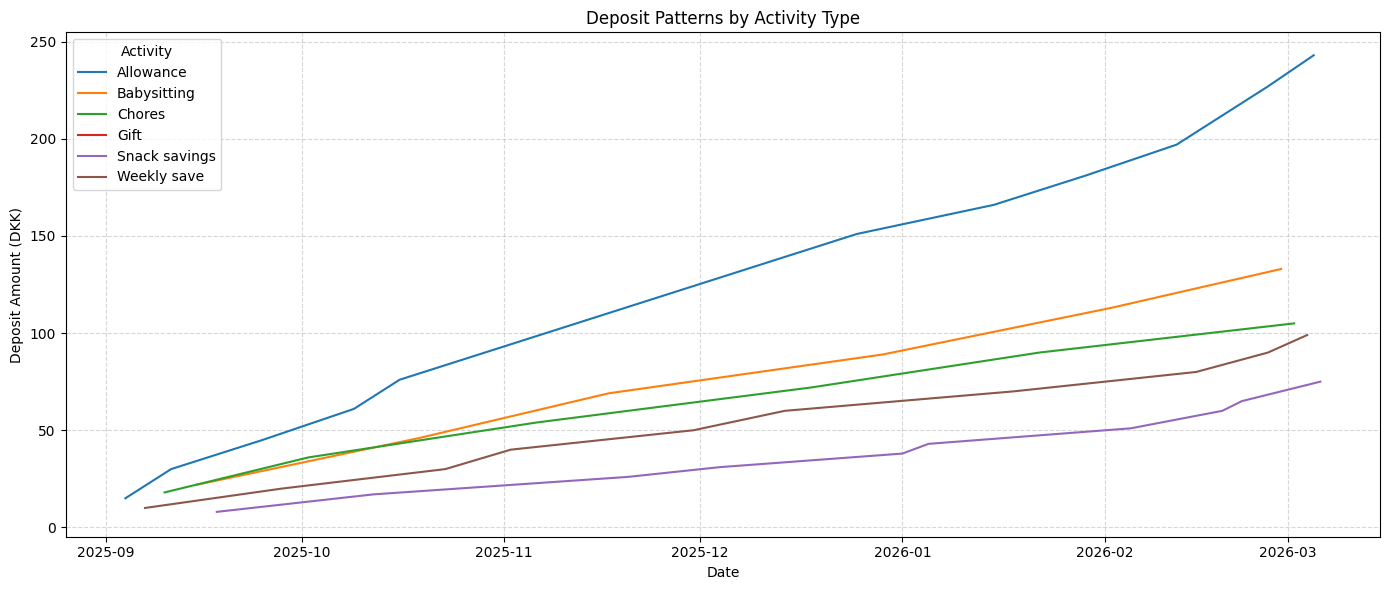

In [78]:
grouped = data.groupby(['date', 'description'])['amount'].sum().unstack()

plt.figure(figsize=(14,6))
for note in grouped.columns:
    temp = grouped[note].cumsum()
    temp = temp[temp.notna()]
    plt.plot(temp.index, temp, label=note)

plt.title("Deposit Patterns by Activity Type")
plt.xlabel("Date")
plt.ylabel("Deposit Amount (DKK)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Activity")
plt.tight_layout()
plt.show()

---
## Linear regression
While forecasting today, we will be using a specific algorithm called **Linear regression**. The idea behind linear regression is to find the best straight-fit line that fits to your data.

### How it works
1. Imagine you’ve saved money over several days. Each day is an `x` value (day number), and each total savings amount is a `y` value.
2. Linear regression finds the best slope (`m`) and intercept (`b`) so your line:
$$
y=m⋅x+b
$$
matches your past savings as closely as possible.
3. Once we have `m` and `b`, we can predict the day you’ll reach your goal by solving for `x`:
$$
x=\frac{\text{Goal Amount}−b​}{m}
$$

## Exercise 2: Understand linear regression
#@TODO: Let's make some simple exercises for them to understand linear regression

---
## Exercise 3: Implement Linear regression for Priority Bank
#@TODO: Write some text

In [ ]:
def find_m():
    pass

In [ ]:
def find_b():
    pass

In [ ]:
def number_of_days_until_goal(goal_amount: float):
    m = find_m()
    b = find_b()
    x = (goal_amount - b)/m